# Roosters

In [75]:
import os

print(os.getcwd())

/Users/jiaming/Business/Business Analytic/Business Analytic Cap/assignment 1/Rooster/notebooks


# 1. Data Preparation

This notebook examines, assesses and prepares the Rooster datasets for customer retention analysis.

The data preparation process includes:
- Loading and inspecting the datasets
- Assessing dataset structure and data types
- Identifying and treating duplicate records
- Assessing missing values
- Correcting inappropriate data types
- Checking data validity and consistency
- Validating relationships between datasets
- Investigating potential outliers
- Exporting cleaned datasets for subsequent analysis

## 1.1 Import Libraries and Load Data

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
# Load datasets from the Excel workbook
customers = pd.read_excel(
    '../datafiles/rooster_a2_retention2.xlsx',
    sheet_name='customers'
)

orders = pd.read_excel(
    '../datafiles/rooster_a2_retention2.xlsx',
    sheet_name='orders'
)

orderlines = pd.read_excel(
    '../datafiles/rooster_a2_retention2.xlsx',
    sheet_name='orderlines'
)

products = pd.read_excel(
    '../datafiles/rooster_a2_retention2.xlsx',
    sheet_name='products'
)

metadata = pd.read_excel(
    '../datafiles/rooster_a2_retention2.xlsx',
    sheet_name='metadata'
)

## 1.2 Dataset Structure and Initial Inspection

An initial inspection is conducted to understand the dimensions, variables and data types of each dataset before cleaning.

In [78]:
# Display number of rows and columns
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Orderlines:", orderlines.shape)
print("Products:", products.shape)
print("Metadata:", metadata.shape)

Customers: (6606, 9)
Orders: (8100, 25)
Orderlines: (21753, 13)
Products: (381, 13)
Metadata: (78, 2)


In [79]:
# Sample records of customers
customers.head()

,customer_email,customer_first_order_date,customer_last_order_date,customer_total_orders,customer_total_spent,coupon_count,first_order_coupon_code,first_order_used_coupon,first_order_acquisition_channel
0,eml_0002a23b87@gmail.example.net,2024-08-07,2024-08-07,1,103.89,1,ROOSTER5,1,Newsletter
1,eml_00078d07d7@gmail.example.net,2024-10-13,2024-10-13,1,44.45,1,ROOSTER15,1,Newsletter
2,eml_000e7aef6e@gmail.example.net,2025-03-15,2025-04-14,2,135.00,0,NaN,0,Direct
3,eml_00163a8915@gmail.example.net,2024-10-06,2024-10-20,2,78.00,1,ROOSTER,1,Google
4,eml_0017ce14ce@gmail.example.net,2024-05-24,2024-12-17,5,332.60,3,ROOSTER5,1,Newsletter


In [80]:
orders.head()

,order_id,customer_email,order_date,order_seq,billing_region,cart_discount,coupon_code,coupon_count,discount_amount_inc_tax,gender_billing,...,order_shipping_inc_tax,order_subtotal_inc_tax,order_total,order_total_fee_inc,order_units,origin,payment_method_title,shipping_method_title,shipping_region,discount_pc
0,ord_0ead7d5a0a,eml_0002a23b87@gmail.example.net,2024-08-07,1,Western Australia,$4.51,ROOSTER5,1,$5.41,f,...,$0.0,$108.3,$103.89,$1,7,Newsletter,Cash on delivery,Courier (free),Western Australia,0.06
1,ord_37c702b877,eml_00078d07d7@gmail.example.net,2024-10-13,1,South Australia,$5.96,ROOSTER15,1,$7.15,f,...,$2.9,$47.7,$44.45,$1,3,Newsletter,Cash on delivery,Pick-up Point,South Australia,0.18
2,ord_a1db24b351,eml_000e7aef6e@gmail.example.net,2025-03-15,1,Australian Capital Territory,$0.0,NaN,0,NaN,m,...,$3.9,$63.6,$67.5,$0,4,Direct,Online payment,Courier,Australian Capital Territory,0.00
3,ord_ba06c61e02,eml_000e7aef6e@gmail.example.net,2025-04-14,2,Australian Capital Territory,$0.0,NaN,0,NaN,m,...,$3.9,$63.6,$67.5,$0,4,Direct,Online payment,Courier,Australian Capital Territory,0.00
4,ord_f63e0df796,eml_00163a8915@gmail.example.net,2024-10-06,1,Queensland,$0.0,NaN,0,NaN,m,...,$2.9,$47.7,$50.6,$0,3,Google,Online payment,Pick-up Point,Queensland,0.00


In [81]:
orderlines.head()

,order_id_line_id,order_id,line_id,pvr_id,cost,item_discount_amount_and_tax,item_price_before_discount_inc,item_price_inc_tax,line_discount_amount_inc_tax,line_price_before_discount_inc,qty_charged,qty_minus_refund,units
0,ord_00015d82ce_1,ord_00015d82ce,1,prd_4cddfce9c2_None_2,12.0,0.0,39.9,39.9,0.0,39.9,1,1,3
1,ord_00015d82ce_2,ord_00015d82ce,2,prd_278d556ee5_var_1fd1568263_2,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0
2,ord_00015d82ce_3,ord_00015d82ce,3,prd_290c6bdfcb_var_51169a8e64_2,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0
3,ord_00015d82ce_4,ord_00015d82ce,4,prd_9662464d29_var_6c9d45e78e_1,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0
4,ord_00102caaba_1,ord_00102caaba,1,prd_bde5653259_var_5fd9db176b_1,4.0,0.0,13.9,13.9,0.0,13.9,1,1,1


In [82]:
products.head()

,pvr_id,product_id,variation_id,range,product_type,pack_size,product_name_main,name,size,price,type,category,colour
0,prd_0133313747_var_07d76d93e7_1,prd_0133313747,var_07d76d93e7,Underwear for Adam,Briefs,1,Rooster Briefs Temptation of the Snake Green,Rooster Briefs Temptation of the Snake Green - M,M,16.9,Variation,"Underwear for Adams of 21st century, 1 Pack",Green
1,prd_0133313747_var_0d0c8c6865_1,prd_0133313747,var_0d0c8c6865,Underwear for Adam,Briefs,1,Rooster Briefs Temptation of the Snake Green,Rooster Briefs Temptation of the Snake Green -...,3XL,16.9,Variation,"Underwear for Adams of 21st century, 1 Pack",Green
2,prd_0133313747_var_2f4a17e288_1,prd_0133313747,var_2f4a17e288,Underwear for Adam,Briefs,1,Rooster Briefs Temptation of the Snake Green,Rooster Briefs Temptation of the Snake Green -...,XXL,16.9,Variation,"Underwear for Adams of 21st century, 1 Pack",Green
3,prd_0133313747_var_4765ef1293_1,prd_0133313747,var_4765ef1293,Underwear for Adam,Briefs,1,Rooster Briefs Temptation of the Snake Green,Rooster Briefs Temptation of the Snake Green -...,4XL,16.9,Variation,"Underwear for Adams of 21st century, 1 Pack",Green
4,prd_0133313747_var_9465f47f95_1,prd_0133313747,var_9465f47f95,Underwear for Adam,Briefs,1,Rooster Briefs Temptation of the Snake Green,Rooster Briefs Temptation of the Snake Green - L,L,16.9,Variation,"Underwear for Adams of 21st century, 1 Pack",Green


In [83]:
# Data types of customers
customers.dtypes

customer_email                             object
customer_first_order_date          datetime64[ns]
customer_last_order_date           datetime64[ns]
customer_total_orders                       int64
customer_total_spent                      float64
coupon_count                                int64
first_order_coupon_code                    object
first_order_used_coupon                     int64
first_order_acquisition_channel            object
dtype: object

In [84]:
orders.dtypes

order_id                    object
customer_email              object
order_date                  object
order_seq                    int64
billing_region              object
cart_discount               object
coupon_code                 object
coupon_count                 int64
discount_amount_inc_tax     object
gender_billing              object
gender_shipping             object
order_cost                  object
order_qty_charged            int64
order_qty_minus_refund       int64
order_refund                object
order_shipping_inc_tax      object
order_subtotal_inc_tax      object
order_total                 object
order_total_fee_inc         object
order_units                  int64
origin                      object
payment_method_title        object
shipping_method_title       object
shipping_region             object
discount_pc                float64
dtype: object

In [85]:
orderlines.dtypes

order_id_line_id                   object
order_id                           object
line_id                             int64
pvr_id                             object
cost                              float64
item_discount_amount_and_tax      float64
item_price_before_discount_inc    float64
item_price_inc_tax                float64
line_discount_amount_inc_tax      float64
line_price_before_discount_inc    float64
qty_charged                         int64
qty_minus_refund                    int64
units                               int64
dtype: object

In [86]:
products.dtypes

pvr_id                object
product_id            object
variation_id          object
range                 object
product_type          object
pack_size              int64
product_name_main     object
name                  object
size                  object
price                float64
type                  object
category              object
colour                object
dtype: object

In [87]:
# Numerical summary
customers.describe().T

,count,mean,min,25%,50%,75%,max,std
customer_first_order_date,6606,2024-10-01 16:57:19.782016256,2023-10-16 00:00:00,2024-06-06 00:00:00,2024-10-16 00:00:00,2024-12-29 00:00:00,2025-06-30 00:00:00,NaN
customer_last_order_date,6606,2024-11-16 19:32:45.122615808,2023-10-16 00:00:00,2024-07-31 00:00:00,2024-12-04 00:00:00,2025-03-13 00:00:00,2025-06-30 00:00:00,NaN
customer_total_orders,6606.0,1.528913,1.0,1.0,1.0,2.0,10.0,0.927009
customer_total_spent,6606.0,72.375982,0.0,31.63,51.6,92.7925,834.41,65.408082
coupon_count,6606.0,0.599909,0.0,0.0,0.0,1.0,7.0,0.79281
first_order_used_coupon,6606.0,0.457009,0.0,0.0,0.0,1.0,1.0,0.498186


In [88]:
orders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_seq,8100.0,1.420000,0.846771,1.0,1.0,1.0,2.00,10.00
coupon_count,8100.0,0.386173,0.488167,0.0,0.0,0.0,1.00,3.00
order_qty_charged,8100.0,1.518395,0.890072,1.0,1.0,1.0,2.00,15.00
order_qty_minus_refund,8100.0,3.296914,2.961600,1.0,1.0,2.0,5.00,35.00
order_units,8100.0,3.138519,2.583931,1.0,1.0,3.0,4.00,30.00
discount_pc,8100.0,0.060302,0.098838,0.0,0.0,0.0,0.12,1.23


## 1.3 Duplicate Handling

In [89]:
# Count completely identical rows
print("Customers duplicates:", customers.duplicated().sum())
print("Orders duplicates:", orders.duplicated().sum())
print("Orderlines duplicates:", orderlines.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())

Customers duplicates: 50
Orders duplicates: 100
Orderlines duplicates: 0
Products duplicates: 0


In [90]:
# Check whether customer identifiers are duplicated
print(
    "Duplicated customer emails:",
    customers['customer_email'].duplicated().sum()
)

# Check whether order identifiers are duplicated
print(
    "Duplicated order IDs:",
    orders['order_id'].duplicated().sum()
)

Duplicated customer emails: 50
Duplicated order IDs: 100


In [91]:
# Remove exact duplicate records
customers = customers.drop_duplicates().copy()
orders = orders.drop_duplicates().copy()
orderlines = orderlines.drop_duplicates().copy()
products = products.drop_duplicates().copy()

# Reset indexes
customers.reset_index(drop=True, inplace=True)
orders.reset_index(drop=True, inplace=True)
orderlines.reset_index(drop=True, inplace=True)
products.reset_index(drop=True, inplace=True)

In [92]:
# Verify duplicates removal
print("Customers duplicates:", customers.duplicated().sum())
print("Orders duplicates:", orders.duplicated().sum())
print("Orderlines duplicates:", orderlines.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())

Customers duplicates: 0
Orders duplicates: 0
Orderlines duplicates: 0
Products duplicates: 0


## 1.4 Missing Values
Missing values are assessed by sheet and resolved according to the meaning of each variable. Values are not removed when a missing value represents a valid business condition.

The treatments are:

- **Customers:** missing first-order coupon codes are labelled `No Coupon` because the cross-tabulation confirms that these customers did not use a coupon.
- **Orders:** missing coupon codes are labelled `No Coupon`; missing discount amounts are set to zero when `discount_pc` is zero; missing categorical descriptors are labelled `Unknown`; missing totals are reconstructed from the complete order components; and missing order costs are derived from order lines.
- **Orderlines:** missing line costs are estimated from the median cost for the same product variation, with the overall line-cost median as a fallback.
- **Products:** missing variation, size and colour attributes are labelled `Unknown`.

In [93]:
# Function for summarising missing values
def missing_summary(df):

    missing = pd.DataFrame({
        'Missing Count': df.isna().sum(),
        'Missing Percentage': df.isna().mean() * 100
    })

    return missing[
        missing['Missing Count'] > 0
    ].round(2)

In [94]:
missing_summary(customers)

,Missing Count,Missing Percentage
first_order_coupon_code,3561,54.32


In [95]:
missing_summary(orders)

,Missing Count,Missing Percentage
coupon_code,4916,61.45
discount_amount_inc_tax,4916,61.45
gender_billing,175,2.19
gender_shipping,204,2.55
order_cost,2,0.02
order_total,500,6.25
payment_method_title,6,0.08
shipping_method_title,27,0.34


In [96]:
missing_summary(orderlines)

,Missing Count,Missing Percentage
cost,10,0.05


In [97]:
missing_summary(products)

,Missing Count,Missing Percentage
variation_id,35,9.19
size,35,9.19
colour,42,11.02


### 1.4.1 Customers

Missing values in the customer dataset are investigated according to their relationship with customer purchasing behaviour.

In particular, missing first-order coupon codes may represent customers who did not use a coupon rather than incomplete customer records.

In [98]:
# Examine relationship between missing coupon codes
# and whether the first order used a coupon
pd.crosstab(
    customers['first_order_coupon_code'].isna(),
    customers['first_order_used_coupon'],
    margins=True
)

first_order_used_coupon,0,1,All
first_order_coupon_code,,,
False,0,2995,2995
True,3561,0,3561
All,3561,2995,6556


In [99]:
customers[
    customers['first_order_coupon_code'].isna()
][
    [
        'first_order_coupon_code',
        'first_order_used_coupon'
    ]
].head(10)

,first_order_coupon_code,first_order_used_coupon
2,NaN,0
5,NaN,0
7,NaN,0
8,NaN,0
9,NaN,0
10,NaN,0
11,NaN,0
13,NaN,0
14,NaN,0
15,NaN,0


In [100]:
# Missing coupon codes indicate that no coupon was used
customers['first_order_coupon_code'] = (
    customers['first_order_coupon_code']
    .fillna('No Coupon')
)

orders['coupon_code'] = (
    orders['coupon_code']
    .fillna('No Coupon')
)

# Missing customer/order descriptors are retained as an explicit category
for col in ['gender_billing', 'gender_shipping', 'payment_method_title', 'shipping_method_title']:
    orders[col] = orders[col].fillna('Unknown')

### 1.4.2 Orders, Orderlines and Products Missing Value Handling

Missing order and line-item values are resolved after numeric conversion so that monetary fields can be calculated safely. Order totals are reconstructed from subtotal, shipping, discount and refund values. Order costs are calculated from the associated order lines. Product attributes and unavailable order descriptors are retained as explicit `Unknown` categories rather than being dropped.

In [101]:
# Inspect orders with missing discount amounts
orders.loc[
    orders['discount_amount_inc_tax'].isna(),
    [
        'discount_amount_inc_tax',
        'discount_pc',
        'cart_discount'
    ]
].head(10)

,discount_amount_inc_tax,discount_pc,cart_discount
2,NaN,0.0,$0.0
3,NaN,0.0,$0.0
4,NaN,0.0,$0.0
5,NaN,0.0,$0.0
7,NaN,0.0,$0.0
9,NaN,0.0,$0.0
10,NaN,0.0,$0.0
11,NaN,0.0,$0.0
12,NaN,0.0,$0.0
13,NaN,0.0,$0.0


In [102]:
# Examine discount percentage where discount amount is missing
orders.loc[
    orders['discount_amount_inc_tax'].isna(),
    'discount_pc'
].value_counts(dropna=False)

discount_pc
0.0    4916
Name: count, dtype: int64

In [103]:
# Missing discount amount represents no discount
orders['discount_amount_inc_tax'] = (
    orders['discount_amount_inc_tax']
    .fillna(0)
)

In [104]:
# Investigate orders with missing order totals
orders.loc[
    orders['order_total'].isna(),
    [
        'order_id',
        'order_subtotal_inc_tax',
        'order_shipping_inc_tax',
        'cart_discount',
        'discount_amount_inc_tax',
        'order_refund',
        'order_total'
    ]
].head(10)

,order_id,order_subtotal_inc_tax,order_shipping_inc_tax,cart_discount,discount_amount_inc_tax,order_refund,order_total
15,ord_ee73457ff9,$34.9,$2.5,$3.49,$3.49,$0.0,NaN
37,ord_4731adba35,$39.9,$2.5,$0.0,0,$0.0,NaN
88,ord_52c8c7445b,$47.7,$3.5,$2.38,$2.38,$0.0,NaN
102,ord_8a1b9073ba,$54.1,$2.9,$0.0,0,$0.0,NaN
110,ord_181dba7b50,$29.8,$3.5,$0.0,0,$0.0,NaN
128,ord_12cf3ef477,$34.9,$3.5,$0.0,0,$0.0,NaN
130,ord_7decafd530,$74.5,$2.9,$9.31,$11.17,$0.0,NaN
143,ord_9aa4a6288b,$63.6,$3.9,$10.34,$12.72,$0.0,NaN
145,ord_0da4eba6b9,$47.7,$2.9,$0.0,0,$0.0,NaN
180,ord_f3741b07a0,$33.79,$3.9,$4.22,$5.06,$0.0,NaN


In [105]:
orders.loc[
    orders['order_total'].isna(),
    [
        'order_subtotal_inc_tax',
        'order_shipping_inc_tax',
        'cart_discount',
        'discount_amount_inc_tax',
        'order_refund'
    ]
].isna().sum()

order_subtotal_inc_tax     0
order_shipping_inc_tax     0
cart_discount              0
discount_amount_inc_tax    0
order_refund               0
dtype: int64

In [106]:
# Inspect orders with missing cost
orders.loc[
    orders['order_cost'].isna()
]

,order_id,customer_email,order_date,order_seq,billing_region,cart_discount,coupon_code,coupon_count,discount_amount_inc_tax,gender_billing,...,order_shipping_inc_tax,order_subtotal_inc_tax,order_total,order_total_fee_inc,order_units,origin,payment_method_title,shipping_method_title,shipping_region,discount_pc
1723,ord_42c7d2b0a6,eml_34d51a1b56@gmail.example.net,2023-10-16,1,New Zealand,$0.0,No Coupon,0,0,m,...,$3.5,$29.9,$33.4,$0,3,Unknown,Direct bank deposit,Courier,New Zealand,0.0
3958,ord_bed9f69702,eml_7d41e3f740@gmail.example.net,2023-10-22,1,New South Wales,$0.0,No Coupon,0,0,m,...,$0.0,$72.7,$73.7,$1,7,Unknown,Cash on delivery,Free shipping,New South Wales,0.0


## 1.5 Data Type Assessment and Correction

From the previous inspect of each dataset, customers, product, orderlines are relatively correct on data types. However the order seems to have important issues with the monetary columns that contains $.

In [107]:
# Monetary columns stored as text
money_cols = [
    'cart_discount',
    'discount_amount_inc_tax',
    'order_cost',
    'order_refund',
    'order_shipping_inc_tax',
    'order_subtotal_inc_tax',
    'order_total',
    'order_total_fee_inc'
]

In [108]:
# Remove dollar signs and convert to numeric
for col in money_cols:
    orders[col] = pd.to_numeric(
        orders[col].str.replace('$', '', regex=False),
        errors='coerce'
    )

In [109]:
# Resolve missing values after numeric conversion
# Product attributes without a recorded value are treated as explicit categories
for col in ['variation_id', 'size', 'colour']:
    products[col] = products[col].fillna('Unknown')

# Blank monetary fields represent no discount, fee, or refund after conversion
for col in ['discount_amount_inc_tax', 'order_total_fee_inc', 'order_refund']:
    orders[col] = orders[col].fillna(0)

# Resolve missing order-line costs using the same product variation first
orderlines['cost_was_imputed'] = orderlines['cost'].isna()
line_cost_by_product = orderlines.groupby('pvr_id')['cost'].transform('median')
orderlines['cost'] = (
    orderlines['cost']
    .fillna(line_cost_by_product)
    .fillna(orderlines['cost'].median())
)

# Reconstruct missing order totals from the complete monetary components
reconstructed_order_total = (
    orders['order_subtotal_inc_tax']
    + orders['order_shipping_inc_tax']
    - orders['discount_amount_inc_tax']
    + orders['order_total_fee_inc']
    - orders['order_refund']
)
orders['order_total_was_imputed'] = orders['order_total'].isna()
orders['order_total'] = orders['order_total'].fillna(
    reconstructed_order_total.round(2)
)

# Derive missing order costs from the associated order lines
order_line_costs = (
    orderlines.assign(
        line_cost=orderlines['cost'] * orderlines['qty_charged']
    )
    .groupby('order_id')['line_cost']
    .sum()
)
orders['order_cost_was_imputed'] = orders['order_cost'].isna()
orders['order_cost'] = orders['order_cost'].fillna(
    orders['order_id'].map(order_line_costs)
)

# Use the observed median only if an order has no usable line-cost total
orders['order_cost'] = orders['order_cost'].fillna(orders['order_cost'].median())

In [110]:
# Convert order date to datetime
orders['order_date'] = pd.to_datetime(
    orders['order_date'],
    errors='coerce'
)

In [111]:
orders.dtypes

order_id                           object
customer_email                     object
order_date                 datetime64[ns]
order_seq                           int64
billing_region                     object
cart_discount                     float64
coupon_code                        object
coupon_count                        int64
discount_amount_inc_tax           float64
gender_billing                     object
gender_shipping                    object
order_cost                        float64
order_qty_charged                   int64
order_qty_minus_refund              int64
order_refund                      float64
order_shipping_inc_tax            float64
order_subtotal_inc_tax            float64
order_total                       float64
order_total_fee_inc                 int64
order_units                         int64
origin                             object
payment_method_title               object
shipping_method_title              object
shipping_region                   

## 1.6 Categorical and Text Consistency

Text variables are checked for unnecessary whitespace and inconsistent formatting to prevent equivalent categories from being treated as different groups.

In [112]:
# Remove leading and trailing whitespace from text variables
for df in [customers, orders, orderlines, products]:

    text_cols = df.select_dtypes(
        include=['object', 'string']
    ).columns

    for col in text_cols:
        df[col] = df[col].str.strip()

In [113]:
customers[
    'first_order_acquisition_channel'
].value_counts(dropna=False)

first_order_acquisition_channel
Direct                 1417
Google                 1361
Facebook               1325
Unknown                1118
Referral                677
Newsletter              356
Instagram               164
Shopping comparison     134
Messenger                 2
Source: An                2
Name: count, dtype: int64

In [114]:
orders[
    'payment_method_title'
].value_counts(dropna=False)

payment_method_title
Online payment         4866
Cash on delivery       2517
Direct bank deposit     291
PayPal                  200
Debit card               99
Credit card              20
Unknown                   6
Apple Pay                 1
Name: count, dtype: int64

In [115]:
orders[
    'shipping_method_title'
].value_counts(dropna=False)

shipping_method_title
Pick-up Point                    4964
Courier                          2184
Courier (free)                    345
Pick-up Point (free)              263
Courier intl                       76
ParcelShop                         62
Unknown                            27
AP courier intl (free)             24
Packet - Courier                   18
Packet - Home delivery             10
AP ParcelShop (free)                9
Packet - Pick-up Point (free)       9
Packet - Home delivery (free)       6
Packet - Courier (free)             1
Free shipping                       1
Packet - Pick-up Point intl         1
Name: count, dtype: int64

In [116]:
products[
    'product_type'
].value_counts(dropna=False)

product_type
Briefs          150
Trunks          138
Full Brief       23
Bikini Brief     23
Thong            23
Bra              19
Gift voucher      5
Name: count, dtype: int64

In [117]:
products[
    'category'
].value_counts(dropna=False)

category
Underwear for Adams of 21st century, 1 Pack        142
4 Pack                                              87
7 Pack                                              46
Underwear for Eves of 21st century,Full Brief       20
Underwear for Eves of 21st century,Bikini Brief     20
Underwear for Eves of 21st century,Thong            20
Underwear for Eves of 21st century,Bras             18
Gift vouchers,Electronic vouchers                    5
Underwear for Eves of 21st century,4 Pack            4
10 Pack                                              4
4 Pack,Build your pack                               4
Underwear for Eves of 21st century,15 Pack           3
Underwear for Eves of 21st century,7 Pack            3
7 Pack,Build your pack                               3
10 Pack,Build your pack                              1
15 Pack,Build your pack                              1
Name: count, dtype: int64

## 1.7 Identifier Validation

Key identifiers are assessed for uniqueness before the datasets are linked. This helps identify duplicate customer or transaction records that could otherwise create incorrect results during merging and aggregation.

In [118]:
print("Customer rows:", len(customers))
print(
    "Unique customer emails:",
    customers['customer_email'].nunique()
)
print(
    "Duplicated customer emails:",
    customers['customer_email'].duplicated().sum()
)

Customer rows: 6556
Unique customer emails: 6556
Duplicated customer emails: 0


In [119]:
print("Order rows:", len(orders))
print(
    "Unique order IDs:",
    orders['order_id'].nunique()
)
print(
    "Duplicated order IDs:",
    orders['order_id'].duplicated().sum()
)

Order rows: 8000
Unique order IDs: 8000
Duplicated order IDs: 0


## 1.8 Dataset Relationship Validation

The relationships between the datasets are validated to ensure that customer, order and product identifiers can be reliably used in subsequent analysis.

The expected relationships are:

Customers → Orders → Order Lines → Products

In [120]:
unknown_customers = (
    set(orders['customer_email'].dropna())
    -
    set(customers['customer_email'].dropna())
)

print(
    "Order customers missing from customers table:",
    len(unknown_customers)
)

Order customers missing from customers table: 0


In [121]:
unknown_orders = (
    set(orderlines['order_id'].dropna())
    -
    set(orders['order_id'].dropna())
)

print(
    "Orderlines without matching orders:",
    len(unknown_orders)
)

Orderlines without matching orders: 0


In [122]:
unknown_products = (
    set(orderlines['pvr_id'].dropna())
    -
    set(products['pvr_id'].dropna())
)

print(
    "Orderline products without matching products:",
    len(unknown_products)
)

Orderline products without matching products: 0


## 1.9 Outlier Assessment

Potential outliers are examined for key numerical variables.

Extreme observations are not automatically removed because they may represent genuine business behaviour. In particular, customers with unusually high spending or purchase frequency may represent Rooster's most valuable and highly retained customers.

In [123]:
customers[
    [
        'customer_total_orders',
        'customer_total_spent'
    ]
].describe()

,customer_total_orders,customer_total_spent
count,6556.000000,6556.000000
mean,1.529286,72.331435
std,0.926545,65.420791
min,1.000000,0.000000
25%,1.000000,31.630000
50%,1.000000,51.600000
75%,2.000000,92.777500
max,10.000000,834.410000


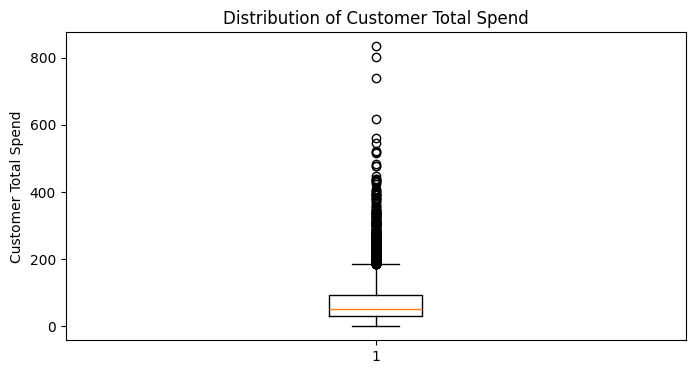

In [124]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    customers['customer_total_spent']
)

plt.ylabel('Customer Total Spend')
plt.title('Distribution of Customer Total Spend')

plt.show()

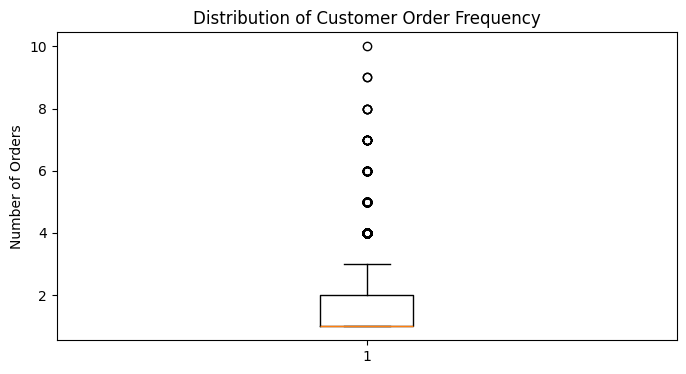

In [125]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    customers['customer_total_orders'].dropna()
)

plt.ylabel('Number of Orders')
plt.title('Distribution of Customer Order Frequency')

plt.show()

In [126]:
customers.nlargest(
    10,
    'customer_total_spent'
)[
    [
        'customer_email',
        'customer_total_orders',
        'customer_total_spent'
    ]
]

,customer_email,customer_total_orders,customer_total_spent
5116,eml_c655218f1b@gmail.example.net,6,834.41
5160,eml_c7fe430fbd@gmail.example.net,4,801.09
5140,eml_c75865885c@gmail.example.net,9,739.36
2441,eml_5e4d84aae5@gmail.example.net,3,616.66
1569,eml_3b2b67c280@gmail.example.net,6,560.42
5702,eml_dcdb0e3f15@gmail.example.net,5,547.33
2562,eml_635bc7f6ec@gmail.example.net,6,523.66
5430,eml_d23b75a2ff@gmail.example.net,4,520.17
5798,eml_e077c87838@gmail.example.net,6,515.52
4627,eml_b3cbdf2694@gmail.example.net,6,484.38


## 1.10 Final Data Quality Assessment

Confirm each dataset on the dimensions, duplicate status, missing values and data types.

This ensures that the prepared datasets are suitable for subsequent exploratory analysis and customer retention analysis.

In [127]:
# Final dimensions
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Orderlines:", orderlines.shape)
print("Products:", products.shape)

Customers: (6556, 9)
Orders: (8000, 27)
Orderlines: (21753, 14)
Products: (381, 13)


In [128]:
# Final dimensions
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Orderlines:", orderlines.shape)
print("Products:", products.shape)

Customers: (6556, 9)
Orders: (8000, 27)
Orderlines: (21753, 14)
Products: (381, 13)


In [129]:
# Confirm missing-value resolution for every sheet
for name, df in {
    'Customers': customers,
    'Orders': orders,
    'Orderlines': orderlines,
    'Products': products
}.items():
    print(f'\n{name} remaining missing values:')
    display(missing_summary(df))


Customers remaining missing values:


,Missing Count,Missing Percentage



Orders remaining missing values:


,Missing Count,Missing Percentage



Orderlines remaining missing values:


,Missing Count,Missing Percentage



Products remaining missing values:


,Missing Count,Missing Percentage


In [130]:
# Collect cleaned tables for export
cleaned_tables = {
    'customers_cleaned': customers,
    'orders_cleaned': orders,
    'orderlines_cleaned': orderlines,
    'products_cleaned': products,
    'metadata': metadata
}

# Export all cleaned tables as separate worksheets in one Excel workbook
excel_path = '../datafiles/rooster_cleaned.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    for sheet_name, table in cleaned_tables.items():
        table.to_excel(writer, sheet_name=sheet_name, index=False)

print(f'Exported {excel_path}')

Exported ../datafiles/rooster_cleaned.xlsx
